# IMporting The Libraries

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Section 1 - Exploratory Data Analysis 

In [4]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
df.shape

(1338, 7)

In [6]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


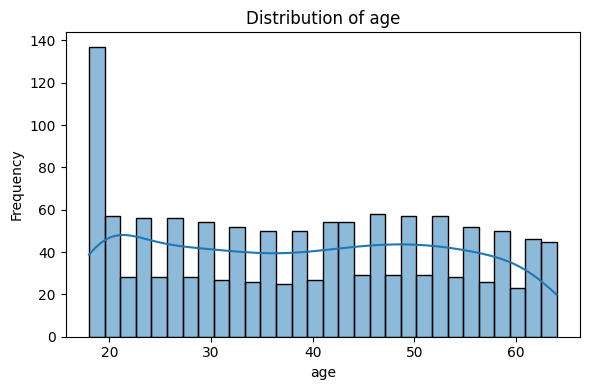

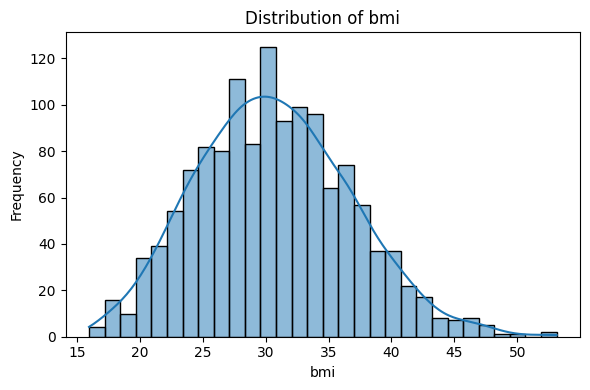

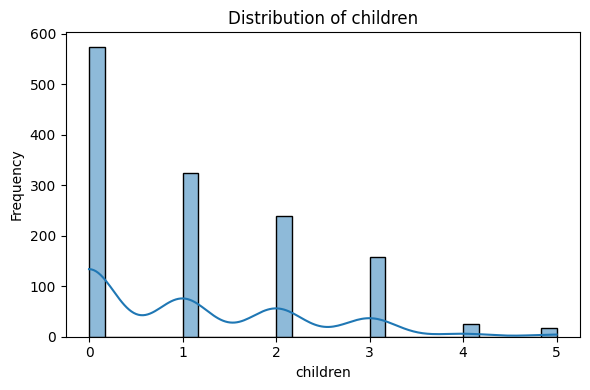

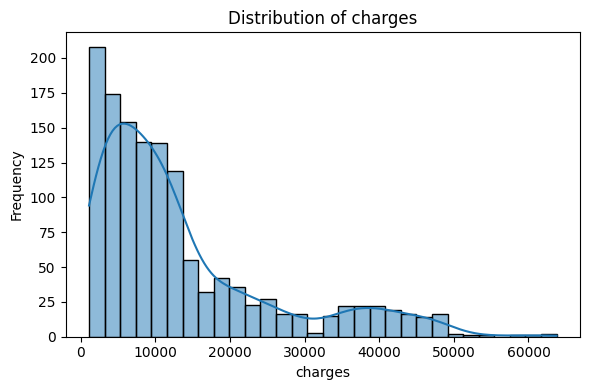

In [8]:
num_columns=['age','bmi','children','charges']
for col in num_columns: 
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

<Axes: xlabel='sex', ylabel='count'>

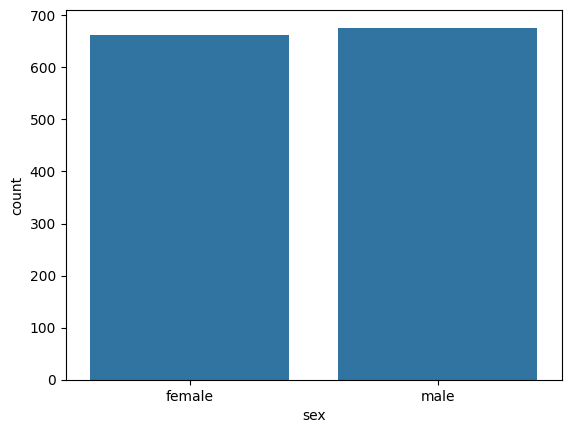

In [9]:
sns.countplot(x=df['sex'])

<Axes: xlabel='children', ylabel='count'>

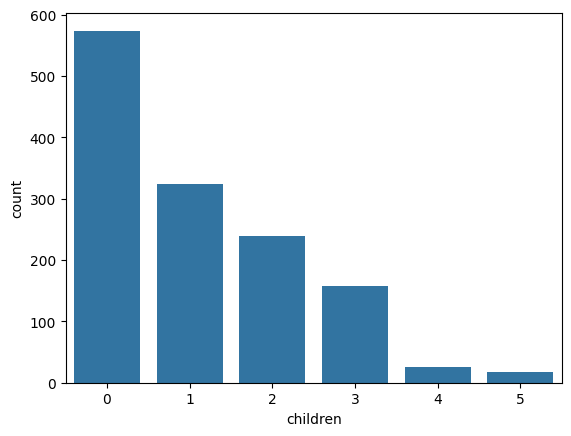

In [10]:
sns.countplot(x=df['children'])

<Axes: xlabel='smoker', ylabel='count'>

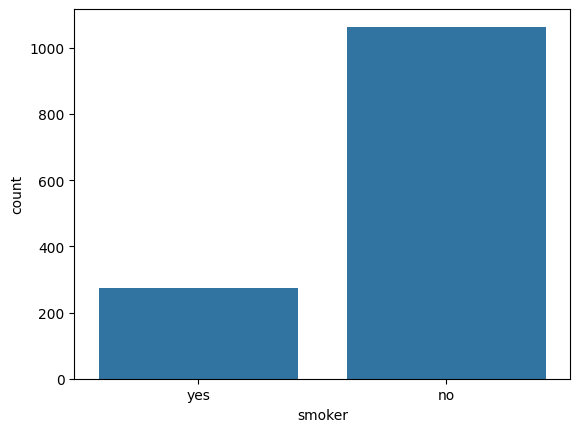

In [11]:
sns.countplot(x=df['smoker'])

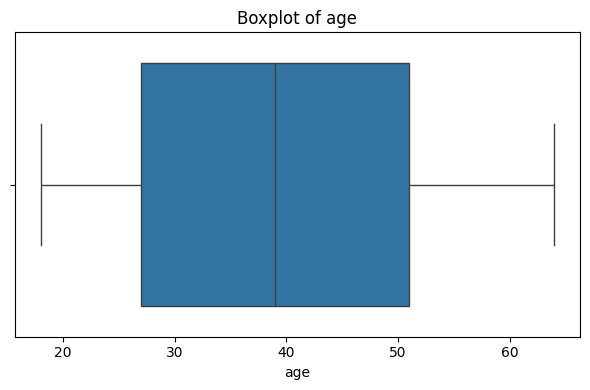

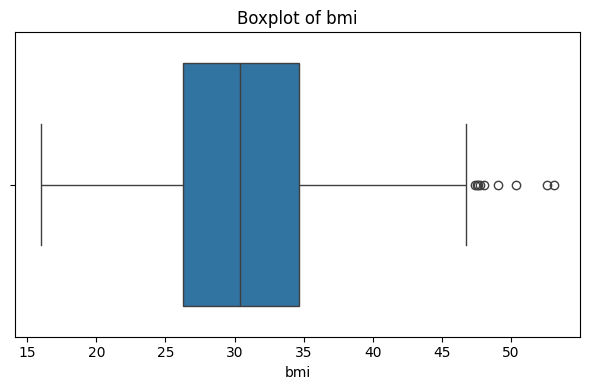

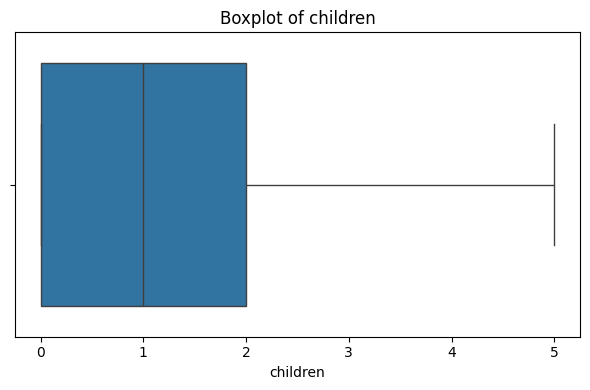

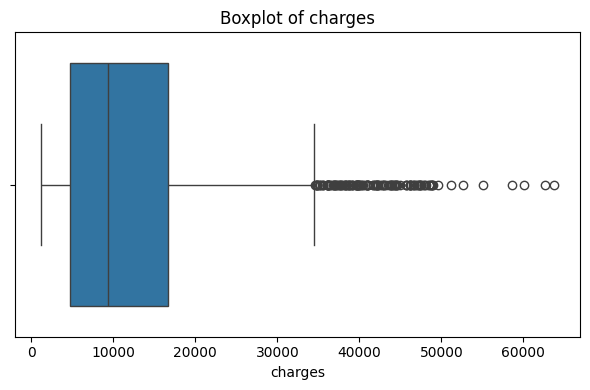

In [12]:
for col in num_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

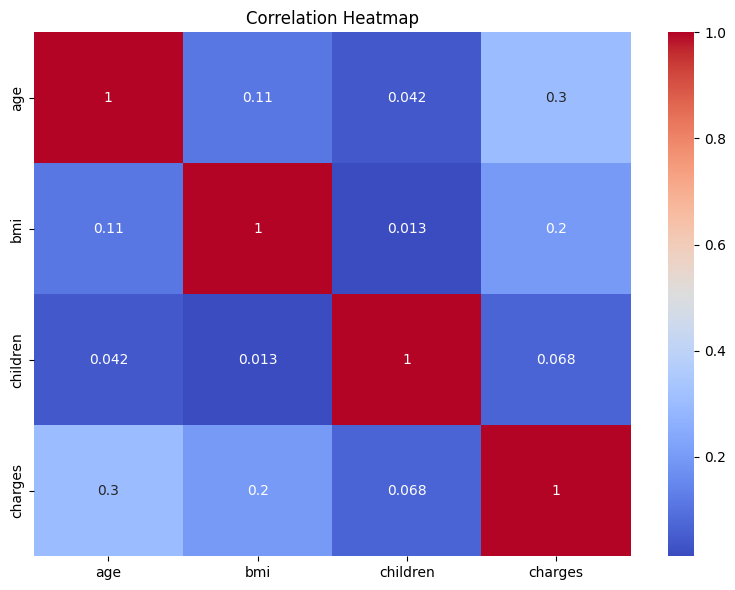

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Section 2 - Data Cleaning and Preprocessing

In [14]:
df_cleaned=df.copy()

In [15]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [16]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [17]:
df_cleaned['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [18]:
df_cleaned['sex']=df_cleaned['sex'].map({'male': 0 , 'female' : 1})

In [19]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [20]:
df_cleaned.rename(columns={
    'sex': 'is_female',
    'smoker': 'is_smoker'
}, inplace=True)

In [21]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [22]:
df_cleaned['is_smoker']=df['smoker']

In [23]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [24]:
df_cleaned['is_smoker']=df_cleaned['is_smoker'].map({'no': 0 , 'yes' : 1})

In [25]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)

In [26]:
df_cleaned=df_cleaned.astype(int)

In [27]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


# Section 3- Feature engineering and Extraction

In [28]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [29]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,Obese
1334,18,1,31,0,0,2205,0,0,0,Obese
1335,18,1,36,0,0,1629,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,1,Overweight


In [30]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True)

In [31]:
df_cleaned=df_cleaned.astype(int)

In [32]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


# Section 4 - Feature Scaling 

In [33]:
from sklearn.preprocessing import StandardScaler
cols_to_scale = ['age', 'bmi', 'children']
scaler = StandardScaler()
df_cleaned[cols_to_scale] = scaler.fit_transform(df_cleaned[cols_to_scale])


In [34]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.438764,1,-0.518122,-0.908614,1,16884,0,0,1,0,1,0
1,-1.509965,0,0.462657,-0.078767,0,1725,0,1,0,0,0,1
2,-0.797954,0,0.462657,1.580926,0,4449,0,1,0,0,0,1
3,-0.441948,0,-1.335438,-0.908614,0,21984,1,0,0,1,0,0
4,-0.513149,0,-0.354659,-0.908614,0,3866,1,0,0,0,1,0


In [35]:

from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

# Calculate Pearson correlation
correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}

# Convert to DataFrame for display
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])

# Show the results
correlation_df.sort_values(by='Pearson Correlation', ascending=False)


,Feature,Pearson Correlation
4,is_smoker,0.787251
0,age,0.299009
10,bmi_category_Obese,0.199533
1,bmi,0.196188
6,region_southeast,0.073981
2,children,0.067999
5,region_northwest,-0.039905
7,region_southwest,-0.043210
3,is_female,-0.057293
8,bmi_category_Normal,-0.103679


In [36]:
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

In [37]:
from scipy.stats import chi2_contingency
import pandas as pd

# Define significance level
alpha = 0.05

# Bin the target variable
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)

# Run Chi-Square test
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

# Convert to DataFrame
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df


,chi2_statistic,p_value,Decision
is_smoker,854.020268,0.0,Reject Null (Keep Feature)
region_southeast,15.208814,0.001647,Reject Null (Keep Feature)
is_female,9.532132,0.022992,Reject Null (Keep Feature)
bmi_category_Obese,8.510101,0.036566,Reject Null (Keep Feature)
region_southwest,5.530825,0.136807,Accept Null (Drop Feature)
bmi_category_Overweight,4.620089,0.201826,Accept Null (Drop Feature)
bmi_category_Normal,3.578987,0.310661,Accept Null (Drop Feature)
region_northwest,1.226112,0.746749,Accept Null (Drop Feature)


In [38]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese',
       'charges_bin'],
      dtype='object')

In [39]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','bmi_category_Obese','region_northwest']]

In [40]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese,region_northwest
0,-1.438764,1,-0.518122,-0.908614,1,16884,0,0,0
1,-1.509965,0,0.462657,-0.078767,0,1725,1,1,0
2,-0.797954,0,0.462657,1.580926,0,4449,1,1,0
3,-0.441948,0,-1.335438,-0.908614,0,21984,0,0,1
4,-0.513149,0,-0.354659,-0.908614,0,3866,0,0,1
...,...,...,...,...,...,...,...,...,...
1333,0.768473,0,-0.027733,1.580926,0,10600,0,1,1
1334,-1.509965,1,0.135731,-0.908614,0,2205,0,1,0
1335,-1.509965,1,0.953046,-0.908614,0,1629,1,1,0
1336,-1.296362,1,-0.845048,-0.908614,0,2007,0,0,0


In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = scaler.fit_transform(final_df)

df_scaled = pd.DataFrame(df_scaled,columns=final_df.columns)

In [54]:
df_scaled.head()

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese,region_northwest
0,-1.438764,1.010519,-0.518122,-0.908614,1.970587,0.298548,-0.611324,-1.058510,-0.566418
1,-1.509965,-0.989591,0.462657,-0.078767,-0.507463,-0.953694,1.635795,0.944724,-0.566418
2,-0.797954,-0.989591,0.462657,1.580926,-0.507463,-0.728672,1.635795,0.944724,-0.566418
3,-0.441948,-0.989591,-1.335438,-0.908614,-0.507463,0.719845,-0.611324,-1.058510,1.765481
4,-0.513149,-0.989591,-0.354659,-0.908614,-0.507463,-0.776832,-0.611324,-1.058510,1.765481


# Section 5 - Making the Model 🔥

In [41]:
from sklearn.model_selection import train_test_split


In [55]:
x = df_scaled.drop('charges', axis=1)
y = df_scaled['charges']

In [56]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import AdaBoostRegressor

In [58]:
lr_model=LinearRegression()
lr_model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
lr_y_pred = lr_model.predict(x_test)

In [65]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,lr_y_pred)
n = x_test.shape[0]
p = x_test.shape[1]
adjusted_r2 = 1 - ((1- r2) * (n-1) / (n - p - 1))
print("r2 score =",r2)
print("adujusted r2 scor =",adjusted_r2)

r2 score = 0.7812672250247643
adujusted r2 scor = 0.7745110003151046


In [62]:
adb_model = AdaBoostRegressor(estimator=lr_model,
                              n_estimators=500,
                              random_state=42)

adb_model.fit(x_train,y_train)


,estimator,LinearRegression()
,n_estimators,500
,learning_rate,1.0
,loss,'linear'
,random_state,42
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
adb_y_pred =  adb_model.predict(x_test)

In [66]:
r2 = r2_score (adb_y_pred,y_test)

n = x_test.shape[0]
p = x_test.shape[1]

adjusted_r2 = 1 - ((1-r2) * (n-1) /(n-p-1))
print("r2 score =",r2)
print("adujusted r2 scor =",adjusted_r2)

r2 score = 0.6538760000395896
adujusted r2 scor = 0.6431849112377236
